In [35]:
import yfinance as yf
import pandas as pd
import numpy as np

# **PROBABILITY ANALYSIS**

In [2]:
df = pd.read_csv("reversion_signals.csv", index_col=0, parse_dates=True)

In [3]:
df.tail()

,Ratio,Support,Resistance,norm_price,bounce_zone,touch_days_ago,avg_15d_at_touch,norm_avg,approach,signal_v1,block1_pass,block2_pass,final_signal
Date,,,,,,,,,,,,,
2026-08-03,0.592087,0.55,0.60,0.841731,rev res bounce,2.0,0.605502,1.110032,NaN,NaN,NaN,NaN,NaN
2026-08-04,0.600730,0.60,0.65,0.014591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-05,0.599582,0.55,0.60,0.991632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-06,0.598114,0.55,0.60,0.962274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-07,0.601152,0.60,0.65,0.023040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
probability_df = df[["Ratio","Support","Resistance","final_signal"]]
probability_df.tail()

,Ratio,Support,Resistance,final_signal
Date,,,,
2026-08-03,0.592087,0.55,0.60,NaN
2026-08-04,0.600730,0.60,0.65,NaN
2026-08-05,0.599582,0.55,0.60,NaN
2026-08-06,0.598114,0.55,0.60,NaN
2026-08-07,0.601152,0.60,0.65,NaN


In [5]:
probability_df[probability_df["final_signal"] == "reverting from support"].shape

(21, 4)

In [8]:
probability_df[probability_df["final_signal"] == "reverting from resistance"].shape

(15, 4)

# **BACKTESTING TOOL**


### **Calculating the MVOL**

In [36]:
def mvol_calc(df, window = 200):
    df = df.copy()

    df["pct_change"] = df["Ratio"].pct_change()
    
    df["vol"] = df["pct_change"].rolling(window).std()

    df["vol"] = df["vol"].bfill()

    df["mvol"] = df["vol"] * np.sqrt(21)

    return df

In [37]:
df = mvol_calc(probability_df,200)

In [41]:
df.head()

,Ratio,Support,Resistance,final_signal,pct_change,vol,mvol
Date,,,,,,,
2021-01-05,0.744865,0.7,0.75,NaN,NaN,0.01162,0.053247
2021-01-06,0.748327,0.7,0.75,NaN,0.004648,0.01162,0.053247
2021-01-07,0.746974,0.7,0.75,NaN,-0.001808,0.01162,0.053247
2021-01-08,0.747425,0.7,0.75,NaN,0.000604,0.01162,0.053247
2021-01-11,0.743811,0.7,0.75,NaN,-0.004835,0.01162,0.053247


In [52]:
print(df["final_signal"].iloc[45])

not pd.isna(df["final_signal"].iloc[45])

nan


False

### **Backtesting**

```text
current_state = FLAT (no open trade)

for each day in the data:
    if current_state == FLAT:
        if today has a signal:
            → ENTER: record entry price, entry date, signal type
            → set peak = entry price
            → current_state = IN_TRADE

    else (current_state == IN_TRADE):
        → update peak (best price seen since entry, direction depends on signal type)
        → calculate drawdown = how far today's price has fallen from that peak, in the unfavorable direction
        → calculate drawdown_ratio = drawdown / mvol_at_entry

        → if drawdown_ratio breaches the user's threshold (e.g., -0.6):
            → EXIT: record exit price, exit date
            → calculate trade return %
            → current_state = FLAT (ready for next signal)
```

In [79]:
trades = []

in_trade = False
entry_date = None
entry_px = None
signal_type = None
peak = None
trough = None

for i in range(len(df)):

    date = df.index[i]
    price = df["Ratio"].iloc[i]
    signal = df["final_signal"].iloc[i]
    mvol = df["mvol"].iloc[i]

    if not in_trade:
        # we check if there is signal

        if not pd.isna(signal) and i + 1 < len(df):
            # if signal is present, then we enter the trade
            # we enter tomorrow to avoid lookahead bias

            entry_date = df.index[i + 1]
            entry_index = i + 1 # for holding period later
            entry_px = df["Ratio"].iloc[i + 1]
            signal_type = signal # need to store to calcualte the peak, darawdown for differnt signal
            peak = entry_px # set peak to entry px
            trough = entry_px
            in_trade = True # update trade state


    elif in_trade:

        if signal_type == "reverting from support": 
            # we are long
            peak = max(peak, price)
            trough = min(trough, price)
            drawdown_pct = (price - peak) / peak
            dd_mvol = drawdown_pct / mvol

        elif signal_type == "reverting from resistance": 
            # we are short
            peak = min(peak, price)
            trough = max(trough, price)
            drawdown_pct = -1*((price - peak) / peak)
            dd_mvol = drawdown_pct / mvol

        if dd_mvol <= - 0.6:
            # we exit

            exit_date = df.index[i]
            exit_px = df["Ratio"].iloc[i]
            return_perc = ((price - entry_px) / entry_px) * 100
            mfe = ((peak - entry_px) / entry_px) * 100
            mae = ((trough - entry_px) / entry_px) * 100

            if signal_type == "reverting from resistance":
                directional_return = -return_perc
                directional_mfe = - mfe
                directional_mae = -mae
            else:
                directional_return = return_perc
                directional_mfe = mfe
                directional_mae = mae

            trades.append({
                "entry_date": entry_date,
                "entry_px": entry_px,
                "signal": signal_type,
                "exit_date": exit_date,
                "exit_px": exit_px,
                "return%": directional_return,
                "peak": peak,
                "trough": trough,
                "mfe": directional_mfe,
                "mae": directional_mae,
                "holding_days": i - entry_index,
            })

            in_trade = False
            entry_date = None
            entry_px = None
            signal_type = None
            peak = None
            trough = None


trades_df = pd.DataFrame(trades)

In [80]:
trades_df

,entry_date,entry_px,signal,exit_date,exit_px,return%,peak,trough,mfe,mae,holding_days
0,2022-12-05,0.918462,reverting from support,2023-01-11,0.898196,-2.206498,0.942282,0.898196,2.593418,-2.206498,26
1,2023-02-22,0.888536,reverting from resistance,2023-04-03,0.897087,-0.962418,0.853429,0.898715,3.951135,-1.145656,28
2,2023-09-12,0.853139,reverting from resistance,2023-09-29,0.832935,2.368148,0.808817,0.856963,5.195160,-0.448301,13
3,2023-10-19,0.813717,reverting from support,2023-11-09,0.812153,-0.192201,0.838695,0.812153,3.069645,-0.192201,15
4,2023-11-23,0.815523,reverting from support,2024-01-24,0.834931,2.379865,0.866250,0.813884,6.220273,-0.200935,41
5,2024-04-03,0.794286,reverting from resistance,2024-06-19,0.723502,8.911580,0.703809,0.799419,11.390976,-0.646298,54
6,2024-10-09,0.613771,reverting from support,2024-11-06,0.636610,3.721085,0.662364,0.613771,7.917027,0.000000,20
7,2025-03-10,0.671922,reverting from support,2025-03-12,0.643308,-4.258578,0.671922,0.643308,0.000000,-4.258578,2
8,2025-05-09,0.640966,reverting from resistance,2025-06-20,0.639158,0.282084,0.614307,0.642920,4.159163,-0.304845,30
9,2025-08-07,0.604872,reverting from support,2025-09-26,0.656515,8.537876,0.680261,0.600848,12.463650,-0.665159,36


### **Summary stats (win rate, EV, std dev, max drawdown, Sharpe)**

In [89]:
def add_equity_curve(trades_df, initial_capital=1_000_000):
    trades_df = trades_df.copy()
    
    trades_df["pnl_$"] = initial_capital * (trades_df["return%"] / 100)
    trades_df["cumulative_pnl_$"] = trades_df["pnl_$"].cumsum()
    trades_df["equity_curve_$"] = initial_capital + trades_df["cumulative_pnl_$"]
    
    return trades_df

In [82]:
def build_backtest_summary(trades_df):
    returns = trades_df["return%"]
    
    wins = returns[returns > 0]
    losses = returns[returns <= 0]
    
    win_rate = len(wins) / len(returns)
    avg_win = wins.mean() if len(wins) > 0 else 0
    avg_loss = losses.mean() if len(losses) > 0 else 0
    ev = (win_rate * avg_win) + ((1 - win_rate) * avg_loss)
    std_dev = returns.std()
    
    running_max = trades_df["equity_curve_$"].cummax()
    drawdown = (trades_df["equity_curve_$"] - running_max) / running_max * 100
    max_drawdown = drawdown.min()
    
    avg_holding_days = trades_df["holding_days"].mean()
    sharpe = (ev / std_dev) * np.sqrt(252 / avg_holding_days) if std_dev != 0 else None
    
    summary = {
        "n_trades": len(trades_df),
        "win_rate_%": win_rate * 100,
        "avg_win_%": avg_win,
        "avg_loss_%": avg_loss,
        "EV_%": ev,
        "std_dev_%": std_dev,
        "max_drawdown_%": max_drawdown,
        "avg_holding_days": avg_holding_days,
        "sharpe": sharpe
    }
    
    return pd.DataFrame([summary])

In [96]:
trades_df = add_equity_curve(trades_df) # for drawdown, need to run 1st then summary
summary_df = build_backtest_summary(trades_df)
summary_df.round(1)

,n_trades,win_rate_%,avg_win_%,avg_loss_%,EV_%,std_dev_%,max_drawdown_%,avg_holding_days,sharpe
0,13,53.8,3.8,-3.2,0.6,4.8,-9.6,24.4,0.4


### Trade-by-trade equity changes

In [86]:
trades_df[["exit_date", "equity_curve_$"]]

,exit_date,equity_curve_$
0,2023-01-11,9.779350e+05
1,2023-04-03,9.683108e+05
2,2023-09-29,9.919923e+05
3,2023-11-09,9.900703e+05
4,2024-01-24,1.013869e+06
5,2024-06-19,1.102985e+06
6,2024-11-06,1.140196e+06
7,2025-03-12,1.097610e+06
8,2025-06-20,1.100431e+06
9,2025-09-26,1.185809e+06


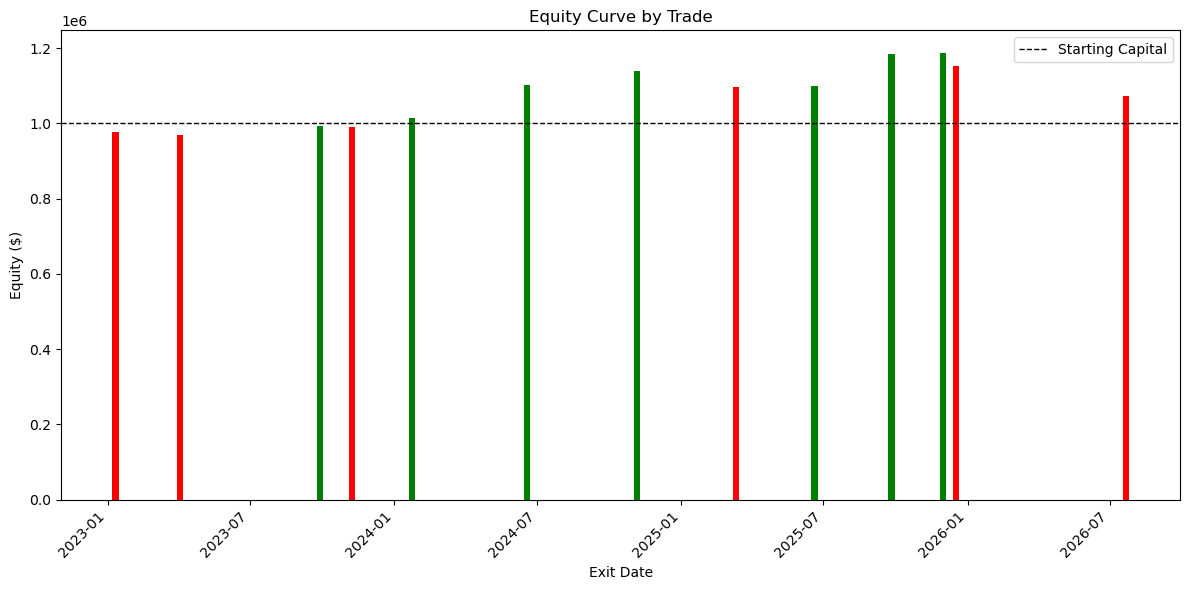

In [88]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["green" if x > 0 else "red" for x in trades_df["pnl_$"]]

ax.bar(trades_df["exit_date"], trades_df["equity_curve_$"], color=colors, width=8)

ax.axhline(1_000_000, color="black", linestyle="--", linewidth=1, label="Starting Capital")

ax.set_ylabel("Equity ($)")
ax.set_xlabel("Exit Date")
ax.set_title("Equity Curve by Trade")
ax.legend()

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()